## A note on what this is

This blender is an **experiment** — a demonstration of how much can still be squeezed out of an
already-solved task with nothing but statistics and arithmetic. There is no new model here, no new
feature, no new data: just a handful of existing submissions combined by weighted voting. The fact
that careful counting alone can nudge the leaderboard is itself the interesting result.

It is also, honestly, **not the cleanest way to solve the problem.** Blending finished submissions
optimizes the leaderboard, not understanding: it leans on scores other people (or earlier runs)
already produced, the gains live in a tiny sliver of disagreement rows, and without ground truth on
the test set every candidate has to be validated blindly by submitting. Treat it as a final polish
on top of real modeling — a way to study ensembling mechanics and harvest the last few thousandths —
not as a substitute for building a better model.

# Blender — Predicting Stellar Class

A two-layer submission blender. Metric is **balanced accuracy**; classes are `['GALAXY', 'QSO', 'STAR']`.

**Layer A — probability core (optional).** When out-of-fold and test probabilities of your own
models are available (`oof_*.npy` + `test_*.npy`), a meta stacker (logistic regression) is trained
with an honest OOF balanced-accuracy estimate. This is the only locally-measurable signal.

**Layer B — hard vote over external submissions.** External submissions carry only class labels
(not probabilities). They enter the blend as weighted votes, where each weight equals the
submission's leaderboard score.

**Merge.** On rows where the external submissions agree unanimously (~98.5%), their label is kept.
On the disagreement rows (~1.5%), a weighted vote decides: the probability core (if present) plus
the external votes.

## Inputs and outputs

This notebook is written to run on Kaggle and locally without edits.

- **`stellar_data` dataset** — mirrors `docs/external/`: a `submissions/` folder with one CSV per
  submission (filename = its leaderboard score, e.g. `0.97007.csv`), plus `star_classification.csv`.
  Optionally also `oof_*.npy` / `test_*.npy` for the probability core.
- **Competition dataset** — the folder that contains `train.csv` and `test.csv`. Its `train.csv`
  supplies the ground-truth labels used to validate the probability core.

Paths are auto-detected by scanning `/kaggle/input/*`. When not on Kaggle, the repository layout
under `competitions/predicting-stellar-class/` is used instead.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import balanced_accuracy_score

CLASSES = ['GALAXY', 'QSO', 'STAR']
C2I = {c: i for i, c in enumerate(CLASSES)}
np.random.seed(42)

PURPLE_BLUE = ['#3B2F8F', '#6A5ACD', '#9D7BE0', '#4169E1', '#7B68EE', '#5B8DEF']
CLASS_PALETTE = {'GALAXY': '#3B2F8F', 'QSO': '#6A5ACD', 'STAR': '#9D7BE0'}
SEQ_CMAP = 'BuPu'
sns.set_theme(style='whitegrid', palette=PURPLE_BLUE)
plt.rcParams['figure.dpi'] = 110

KAGGLE_INPUT = Path('/kaggle/input')
ON_KAGGLE = KAGGLE_INPUT.exists()


def find_dir(predicate, roots):
    for root in roots:
        if not root.exists():
            continue
        for p in [root, *sorted(root.rglob('*'))]:
            if p.is_dir() and predicate(p):
                return p
    return None


if ON_KAGGLE:
    search_roots = sorted(KAGGLE_INPUT.iterdir())
    SUBS_DIR = find_dir(lambda p: p.name == 'submissions' and any(p.glob('*.csv')), search_roots)
    assert SUBS_DIR is not None, 'no submissions/ folder found under /kaggle/input'
    STELLAR_DIR = SUBS_DIR.parent
    COMP_DIR = find_dir(lambda p: (p / 'train.csv').exists(), search_roots)
    OUT_DIR = Path('/kaggle/working')
else:
    REPO = Path('competitions/predicting-stellar-class') if Path('competitions').exists() else Path('..')
    STELLAR_DIR = REPO / 'docs' / 'external'
    SUBS_DIR = STELLAR_DIR / 'submissions'
    COMP_DIR = REPO / 'data_processed'
    OUT_DIR = REPO / 'data_processed'

print('on kaggle :', ON_KAGGLE)
print('stellar   :', STELLAR_DIR)
print('subs      :', SUBS_DIR)
print('comp      :', COMP_DIR)
print('out       :', OUT_DIR)

on kaggle : False
stellar   : ../docs/external
subs      : ../docs/external/submissions
comp      : ../data_processed
out       : ../data_processed


## 1. External submissions and their leaderboard-score weights

Every CSV in the `submissions/` folder is one external submission. The filename is parsed as its
leaderboard score and used directly as its voting weight. All submissions are aligned on `id`.

In [2]:
sub_files = sorted(SUBS_DIR.glob('*.csv'))
assert sub_files, f'no submissions found in {SUBS_DIR}'

scores = {f.stem: float(f.stem) for f in sub_files}
subs = {f.stem: pd.read_csv(f).sort_values('id').reset_index(drop=True) for f in sub_files}

ref_id = subs[sub_files[0].stem]['id'].values
for name, df in subs.items():
    assert np.array_equal(df['id'].values, ref_id), f'{name}: id mismatch'

names = list(subs)
print(f'{len(names)} submissions, {len(ref_id)} rows')

L = np.column_stack([subs[n]['class'].map(C2I).values for n in names])
S = np.array([scores[n] for n in names])

# --- Weight stretching ------------------------------------------------------
# Raw LB scores barely differ (~0.969..0.970), so weighting by the raw score is
# almost a uniform vote. We rescale the scores so the gap between submissions
# actually drives the vote on disagreement rows.
#   'raw'     : w = score                       (original behaviour)
#   'shifted' : w = score - min(score) + eps    (weight ~ "how much better than worst")
#   'softmax' : w = softmax((score-max)/T)      (sharper; smaller T -> winner-takes-more)
WEIGHT_MODE = 'softmax'
SOFTMAX_T = 0.0005

def make_weights(s, mode=WEIGHT_MODE, T=SOFTMAX_T):
    s = np.asarray(s, dtype=float)
    if mode == 'raw':
        return s.copy()
    if mode == 'shifted':
        return s - s.min() + 1e-3
    if mode == 'softmax':
        e = np.exp((s - s.max()) / T)
        return e / e.sum()
    raise ValueError(mode)

W = make_weights(S)
print(f'\nweight mode: {WEIGHT_MODE}' + (f' (T={SOFTMAX_T})' if WEIGHT_MODE == 'softmax' else ''))
for n, raw, w in zip(names, S, W):
    print(f'  {n}: score={raw:.5f}  weight={w:.5f}', dict(subs[n]['class'].value_counts()))

6 submissions, 247435 rows

weight mode: softmax (T=0.0005)
  0.96874: score=0.96874  weight=0.01563 {'GALAXY': 156899, 'QSO': 51204, 'STAR': 39332}
  0.96973: score=0.96973  weight=0.11319 {'GALAXY': 157408, 'QSO': 51515, 'STAR': 38512}
  0.96996: score=0.96996  weight=0.17931 {'GALAXY': 157026, 'QSO': 51391, 'STAR': 39018}
  0.97003: score=0.97003  weight=0.20625 {'GALAXY': 157186, 'QSO': 51379, 'STAR': 38870}
  0.97007: score=0.97007  weight=0.22343 {'GALAXY': 157349, 'QSO': 51368, 'STAR': 38718}
  0.97015: score=0.97015  weight=0.26220 {'GALAXY': 157202, 'QSO': 51376, 'STAR': 38857}


## 2. Disagreement region

Rows where every submission already agrees carry no information for blending. The blend can only
ever change a label inside the disagreement region, so it is worth measuring how small that is.

In [3]:
unanimous = np.all(L == L[:, [0]], axis=1)
disagree = ~unanimous
print(f'unanimous rows: {unanimous.sum()} ({unanimous.mean()*100:.2f}%)')
print(f'disagree  rows: {disagree.sum()} ({disagree.mean()*100:.2f}%)')

unanimous rows: 243833 (98.54%)
disagree  rows: 3602 (1.46%)


### Submission agreement matrix

A blend can only help if its members make *different* mistakes. This heatmap shows the pairwise
agreement (share of identical predictions) between every pair of submissions. Bright near-100%
blocks reveal near-duplicate submissions: they vote together and dominate any plain majority vote,
so the effective diversity is lower than the submission count suggests.

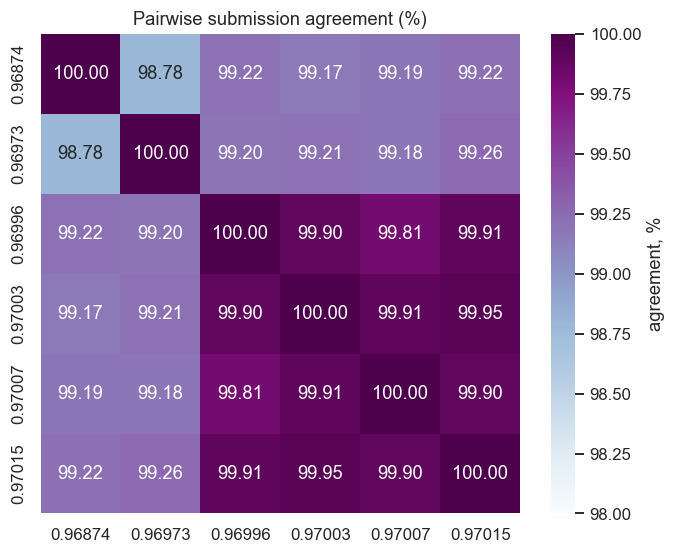

In [4]:
agree = np.zeros((len(names), len(names)))
for a in range(len(names)):
    for b in range(len(names)):
        agree[a, b] = (L[:, a] == L[:, b]).mean()

plt.figure(figsize=(6.5, 5.2))
sns.heatmap(pd.DataFrame(agree * 100, index=names, columns=names),
            annot=True, fmt='.2f', cmap=SEQ_CMAP, square=True,
            vmin=98, vmax=100, cbar_kws={'label': 'agreement, %'})
plt.title('Pairwise submission agreement (%)')
plt.tight_layout(); plt.show()

## 2b. Leave-one-submission-out validation (no ground truth)

There is no test-set ground truth, so Layer B normally can only be judged by submitting. A cheap
local proxy: hold out one submission, blend the remaining ones, and measure how well the blend
reproduces the held-out labels. We report it as **balanced accuracy** against the held-out
submission (treating it as pseudo-truth), so the imbalance is reflected the same way the real metric
is. The absolute number is not the leaderboard score — but it lets us compare weight schemes and the
class prior *without spending submissions*: a setting that consistently agrees better with strong
held-out submissions is the safer bet.

In [5]:
# --- Class prior --------------------------------------------------------------
# The metric is BALANCED accuracy, but a plain weighted vote optimises plain
# accuracy and quietly underweights the rare classes (STAR is the known weak
# spot). Multiplying the accumulated votes by 1/frequency makes a vote for a
# rare class "worth more", the same idea as class_weight='balanced'.
#   USE_CLASS_PRIOR=False  -> exact original behaviour.
USE_CLASS_PRIOR = True
CLASS_FREQ = np.array([0.65, 0.20, 0.14])           # GALAXY, QSO, STAR (from EDA)
CLASS_PRIOR = (1.0 / CLASS_FREQ) if USE_CLASS_PRIOR else np.ones(3)
CLASS_PRIOR = CLASS_PRIOR / CLASS_PRIOR.min()        # normalise so the cheapest class == 1
print('class prior (GALAXY,QSO,STAR):', np.round(CLASS_PRIOR, 3))


def weighted_vote(label_mat, weights, prior=CLASS_PRIOR):
    """Hard weighted vote -> predicted class index per row."""
    m = label_mat.shape[0]
    v = np.zeros((m, 3))
    for j in range(label_mat.shape[1]):
        np.add.at(v, (np.arange(m), label_mat[:, j]), weights[j])
    return (v * prior).argmax(1)


# Leave-one-submission-out: blend the rest, score against the held-out sub.
print(f'\nLOSO balanced accuracy vs held-out submission (weight={WEIGHT_MODE}, prior={USE_CLASS_PRIOR})')
loso = {}
for h in range(len(names)):
    keep = [j for j in range(len(names)) if j != h]
    pred = weighted_vote(L[:, keep], make_weights(S[keep]))
    loso[names[h]] = balanced_accuracy_score(L[:, h], pred)
    print(f'  held-out {names[h]} (score {S[h]:.5f}): {loso[names[h]]:.5f}')
print(f'  mean: {np.mean(list(loso.values())):.5f}  '
      f'| weighted-by-score: {np.average(list(loso.values()), weights=S):.5f}')

class prior (GALAXY,QSO,STAR): [1.    3.25  4.643]

LOSO balanced accuracy vs held-out submission (weight=softmax, prior=True)
  held-out 0.96874 (score 0.96874): 0.98909


  held-out 0.96973 (score 0.96973): 0.99078
  held-out 0.96996 (score 0.96996): 0.99857
  held-out 0.97003 (score 0.97003): 0.99942
  held-out 0.97007 (score 0.97007): 0.99887
  held-out 0.97015 (score 0.97015): 0.99946
  mean: 0.99603  | weighted-by-score: 0.99603


## 3. Layer A — probability core (only if artifacts are present)

The core looks for `oof_*.npy` (row-aligned to the competition `train.csv`, class order = `CLASSES`)
and matching `test_*.npy`. Each pair is one base model; they are concatenated and fed to a
logistic-regression meta-model. The OOF balanced accuracy is computed honestly via
`cross_val_predict`. Ground-truth labels come from the competition `train.csv`.

If no artifacts are found, the core stays off and the blender runs as a pure weighted hard vote.

In [6]:
npy_roots = [STELLAR_DIR, COMP_DIR, OUT_DIR]
oof_paths, test_paths = [], []
for root in npy_roots:
    if root and root.exists():
        oof_paths += sorted(root.rglob('oof_*.npy'))
        test_paths += sorted(root.rglob('test_*.npy'))

have_probs = bool(oof_paths) and bool(test_paths)
print('probability artifacts:', 'FOUND' if have_probs else 'none -> hard-vote mode')
for p in oof_paths + test_paths:
    print('  ', p)

core_test_proba = None
core_oof_ba = None
meta = meta_oof = y = None

if have_probs:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_predict, StratifiedKFold

    train_csv = COMP_DIR / 'train.csv'
    train_parquet = COMP_DIR / 'train_fe.parquet'
    if train_csv.exists():
        y = pd.read_csv(train_csv, usecols=['class'])['class'].map(C2I).values
    else:
        y = pd.read_parquet(train_parquet)['target'].values

    suffix = lambda p: p.stem.split('_', 1)[1]
    oof_map = {suffix(p): np.load(p) for p in oof_paths}
    test_map = {suffix(p): np.load(p) for p in test_paths}
    keys = [k for k in oof_map if k in test_map]
    assert keys, 'no oof_*/test_* pairs with a shared suffix'
    print('models in stack:', keys)

    for k in keys:
        assert oof_map[k].shape[0] == len(y), f'{k}: oof rows {oof_map[k].shape} != {len(y)}'
        assert test_map[k].shape[0] == len(ref_id), f'{k}: test rows != {len(ref_id)}'

    Xoof = np.hstack([oof_map[k] for k in keys])
    Xtest = np.hstack([test_map[k] for k in keys])

    meta = LogisticRegression(max_iter=2000, C=1.0, multi_class='multinomial')
    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    meta_oof = cross_val_predict(meta, Xoof, y, cv=skf, method='predict_proba')
    core_oof_ba = balanced_accuracy_score(y, meta_oof.argmax(1))
    print(f'\nprobability core OOF balanced accuracy = {core_oof_ba:.5f}')

    meta.fit(Xoof, y)
    core_test_proba = meta.predict_proba(Xtest)
    assert list(meta.classes_) == list(range(3)), f'unexpected class order: {meta.classes_}'

probability artifacts: none -> hard-vote mode


## 4. Merge the layers into the final blend

For each row a weighted vote is accumulated across the three classes:

- every external submission adds its weight `W[i]` to the class it predicted;
- the probability core (if present) adds `CORE_WEIGHT * proba[class]` as a soft vote.

`CORE_WEIGHT` defaults to the sum of external weights, giving the locally-validated core a say
comparable to the whole external panel. Setting it to `0` recovers a pure external hard vote.
The argmax over the accumulated votes is the final label.

In [7]:
CORE_WEIGHT = float(W.sum()) if core_test_proba is not None else 0.0
print(f'CORE_WEIGHT = {CORE_WEIGHT:.4f} | sum of external weights = {W.sum():.4f}')

n = len(ref_id)
votes = np.zeros((n, 3), dtype=np.float64)
for j in range(len(names)):
    np.add.at(votes, (np.arange(n), L[:, j]), W[j])
if core_test_proba is not None:
    votes += CORE_WEIGHT * core_test_proba

# Class prior reweights toward the rare classes for balanced accuracy (see 2b).
blend_idx = (votes * CLASS_PRIOR).argmax(1)
blend_lbl = np.array(CLASSES)[blend_idx]

best_name = max(names, key=lambda x: scores[x])
best_idx = L[:, names.index(best_name)]
print(f'\nbest external submission: {best_name}')
print(f'blend differs from it on {(blend_idx != best_idx).sum()} rows')
print('all changes inside disagreement region:', bool(np.all(disagree[blend_idx != best_idx])))
print('blend class distribution:', dict(zip(*np.unique(blend_lbl, return_counts=True))))

CORE_WEIGHT = 0.0000 | sum of external weights = 1.0000

best external submission: 0.97015
blend differs from it on 221 rows
all changes inside disagreement region: True
blend class distribution: {'GALAXY': 156989, 'QSO': 51394, 'STAR': 39052}


### Where the blend lands

Two views of the result. **Left:** the per-class prediction counts of each external submission and
of the blend — the blend should sit *inside* the envelope of its inputs, not invent an extreme
distribution. **Right:** among the rows the blend changed relative to the best single submission,
how those labels moved (from → to), restricted to the disagreement region. This makes concrete the
handful of rows where blending actually does work.

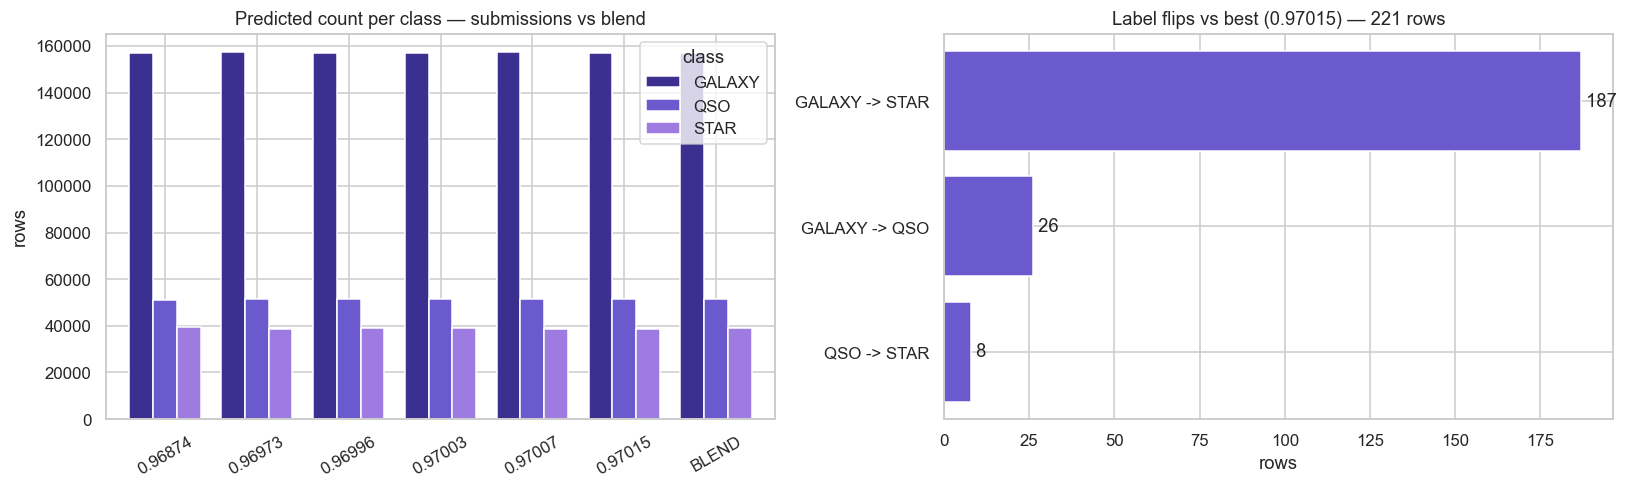

In [8]:
dist = pd.DataFrame({n: subs[n]['class'].value_counts() for n in names}).reindex(CLASSES)
dist['BLEND'] = pd.Series(Counter(blend_lbl)).reindex(CLASSES)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))

dist.T.plot(kind='bar', ax=ax[0], width=0.78,
            color=[CLASS_PALETTE[c] for c in CLASSES])
ax[0].set_title('Predicted count per class — submissions vs blend')
ax[0].set_ylabel('rows'); ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=30)
ax[0].legend(title='class')

changed = blend_idx != best_idx
moves = (pd.Series([f'{CLASSES[best_idx[k]]} -> {CLASSES[blend_idx[k]]}'
                    for k in np.where(changed)[0]])
         .value_counts().sort_values())
ax[1].barh(moves.index, moves.values, color='#6A5ACD')
for y, v in enumerate(moves.values):
    ax[1].text(v, y, f' {v}', va='center')
ax[1].set_title(f'Label flips vs best ({best_name}) — {changed.sum()} rows')
ax[1].set_xlabel('rows')

plt.tight_layout(); plt.show()

## 5. Optional per-class thresholds over the probability core

The project's weak spot is STAR recall. With a probability core available, per-class multipliers
can shift the decision boundary toward STAR. The multipliers are tuned on OOF (honestly) and then
applied to the test votes. Disabled by default — enable deliberately and validate by submitting.

In [9]:
APPLY_THRESHOLDS = False

if APPLY_THRESHOLDS and core_test_proba is not None:
    from itertools import product
    grid = np.linspace(0.8, 1.4, 13)
    best_ba, best_m = core_oof_ba, (1.0, 1.0, 1.0)
    for mg, mq, ms in product(grid, grid, grid):
        m = np.array([mg, mq, ms])
        ba = balanced_accuracy_score(y, (meta_oof * m).argmax(1))
        if ba > best_ba:
            best_ba, best_m = ba, (mg, mq, ms)
    print(f'multipliers {best_m} -> OOF BA {best_ba:.5f} (was {core_oof_ba:.5f})')
    m = np.array(best_m)
    blend_idx = (votes * CLASS_PRIOR * m).argmax(1)
    blend_lbl = np.array(CLASSES)[blend_idx]
    print('new class distribution:', dict(zip(*np.unique(blend_lbl, return_counts=True))))
else:
    print('thresholds not applied')

thresholds not applied


## 6. Write the submission

The result is written to the working directory as `submission.csv` (`id,class`), ready to submit.

In [10]:
sub = pd.DataFrame({'id': ref_id, 'class': blend_lbl})
assert sub['class'].isin(CLASSES).all()
out_path = OUT_DIR / 'submission.csv'
sub.to_csv(out_path, index=False)
print('written:', out_path, sub.shape)
sub.head()

written: ../data_processed/submission.csv (247435, 2)


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
